In [21]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize, OptimizeResult
from sklearn.metrics import mean_squared_error, root_mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Preparing synthetic data

In [22]:
RANDOM_STATE = 264034
N_SAMPLES = 2634

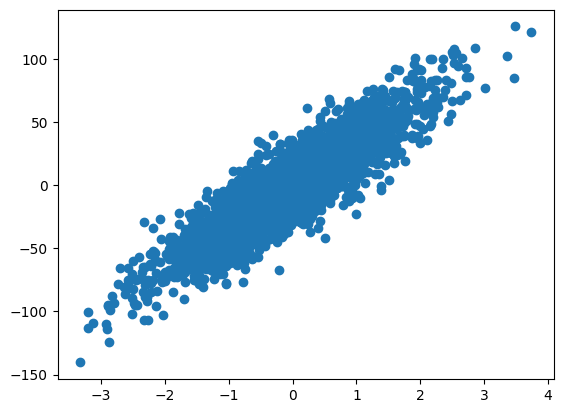

In [23]:
X, y = make_regression(n_samples=N_SAMPLES, random_state=RANDOM_STATE, n_features=1, noise=16) # type: ignore
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)

plt.figure()
plt.scatter(X, y)
plt.show()

# Linear Regressions Implementation

In [24]:
class AnalyticalLinearRegression:
    def fit(self, X : np.ndarray, y : np.ndarray) -> None:
        self.weights = np.linalg.inv((X.T @ X)) @ X.T @ y

    def predict(self, X) -> np.ndarray:
        return X @ self.weights

In [25]:
class NumericalLinearRegression:
    def _loss(self, weights : np.ndarray, X : np.ndarray, y : np.ndarray):
        number_of_samples = X.shape[1]
        return ((y - X.T @ weights).T @ (y - X.T @ weights)) / number_of_samples

    def fit(self, X : np.ndarray, y : np.ndarray):
        X = X.T
        initial_weights = np.zeros(X.shape[0])
        result : OptimizeResult = minimize(self._loss, initial_weights, args=(X, y) ,method='Powell')
        self.weights = result.x

    def predict(self, X):
        return X @ self.weights

# Comparision of Numerical and Analytical Regression for synthetic data

### Training

In [26]:
analytical_lin_reg = AnalyticalLinearRegression()
analytical_lin_reg.fit(X_train, y_train)

numerical_lin_reg = NumericalLinearRegression()
numerical_lin_reg.fit(X_train, y_train)

### Testing

In [27]:
line = analytical_lin_reg.predict(X_test)
line_num = numerical_lin_reg.predict(X_test)

mse_analytical = mean_squared_error(y_test, line)
mse_numerical = mean_squared_error(y_test, line_num)
rmse_analytical = root_mean_squared_error(y_test, line)
rmse_numerical = root_mean_squared_error(y_test, line_num)

print(f"MSE Analytical: {mse_analytical}")
print(f"MSE Numerical: {mse_numerical}")
print(f"RMSE Analytical: {rmse_analytical}")
print(f"RMSE Numerical: {rmse_numerical}")

MSE Analytical: 263.47547157910776
MSE Numerical: 263.47547169982886
RMSE Analytical: 16.231927537390863
RMSE Numerical: 16.231927541109492


### Visualization

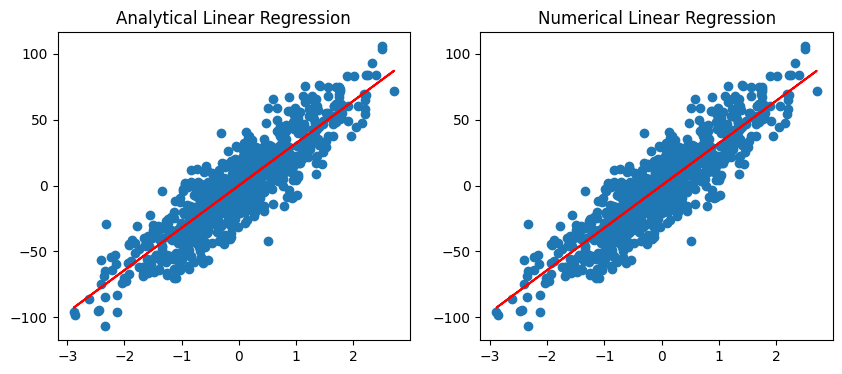

In [28]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Analytical Linear Regression")
plt.scatter(X_test, y_test)
plt.plot(X_test, line, c = 'red')

plt.subplot(1, 2, 2)
plt.title("Numerical Linear Regression")
plt.scatter(X_test, y_test)
plt.plot(X_test, line_num, c = 'red')

plt.show()

# Comparision of analytical implementation on real data

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### Fetching dataset

In [30]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
airfoil_self_noise = fetch_ucirepo(id=291) 
  
# data (as pandas dataframes) 
X = airfoil_self_noise.data.features 
y = airfoil_self_noise.data.targets 
  
# metadata 
print(airfoil_self_noise.metadata) 
  
# variable information 
print(airfoil_self_noise.variables)

{'uci_id': 291, 'name': 'Airfoil Self-Noise', 'repository_url': 'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise', 'data_url': 'https://archive.ics.uci.edu/static/public/291/data.csv', 'abstract': 'NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel.', 'area': 'Physics and Chemistry', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 1503, 'num_features': 5, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['scaled-sound-pressure'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Mar 29 2024', 'dataset_doi': '10.24432/C5VW2C', 'creators': ['Thomas Brooks', 'D. Pope', 'Michael Marcolini'], 'intro_paper': None, 'additional_info': {'summary': 'The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel speeds and angles of

### Inspecting dataset

In [31]:
print(X)
print(y)

      frequency  attack-angle  chord-length  free-stream-velocity  \
0           800           0.0        0.3048                  71.3   
1          1000           0.0        0.3048                  71.3   
2          1250           0.0        0.3048                  71.3   
3          1600           0.0        0.3048                  71.3   
4          2000           0.0        0.3048                  71.3   
...         ...           ...           ...                   ...   
1498       2500          15.6        0.1016                  39.6   
1499       3150          15.6        0.1016                  39.6   
1500       4000          15.6        0.1016                  39.6   
1501       5000          15.6        0.1016                  39.6   
1502       6300          15.6        0.1016                  39.6   

      suction-side-displacement-thickness  
0                                0.002663  
1                                0.002663  
2                                0.0026

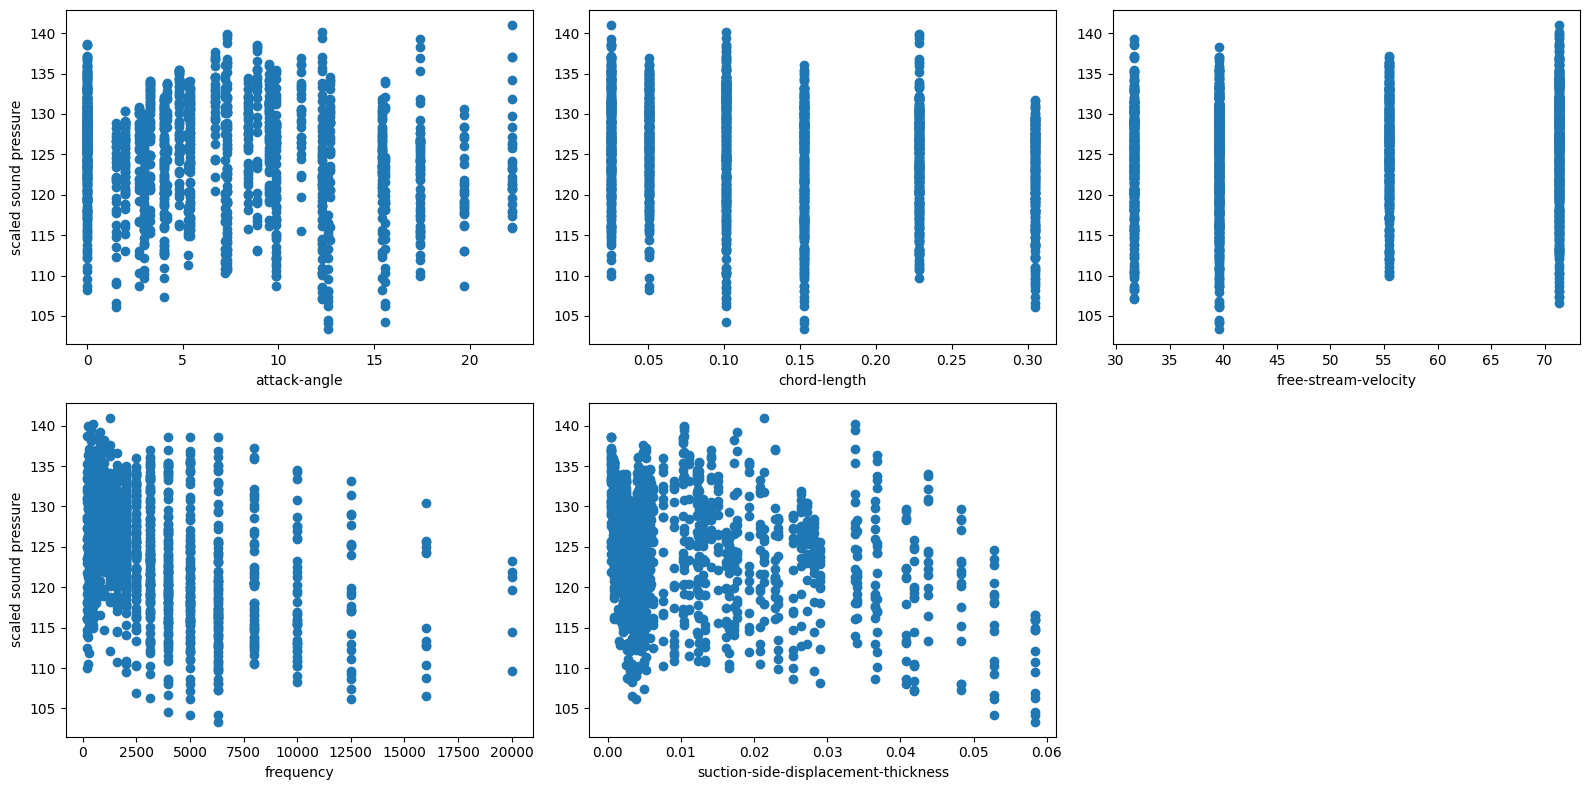

In [32]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
plt.scatter(X['attack-angle'], y['scaled-sound-pressure'])
plt.xlabel('attack-angle')
plt.ylabel('scaled sound pressure')

plt.subplot(2, 3, 2)
plt.scatter(X['chord-length'], y['scaled-sound-pressure'])
plt.xlabel('chord-length')
# plt.ylabel('scaled sound pressure')

plt.subplot(2, 3, 3)
plt.scatter(X['free-stream-velocity'], y['scaled-sound-pressure'])
plt.xlabel('free-stream-velocity')
# plt.ylabel('scaled sound pressure')

plt.subplot(2, 3, 4)
plt.scatter(X['frequency'], y['scaled-sound-pressure'])
plt.xlabel('frequency')
plt.ylabel('scaled sound pressure')

plt.subplot(2, 3, 5)
plt.scatter(X['suction-side-displacement-thickness'], y['scaled-sound-pressure'])
plt.xlabel('suction-side-displacement-thickness')
# plt.ylabel('scaled sound pressure')

plt.tight_layout()
plt.show()

### Preprocessing

(1503, 21)


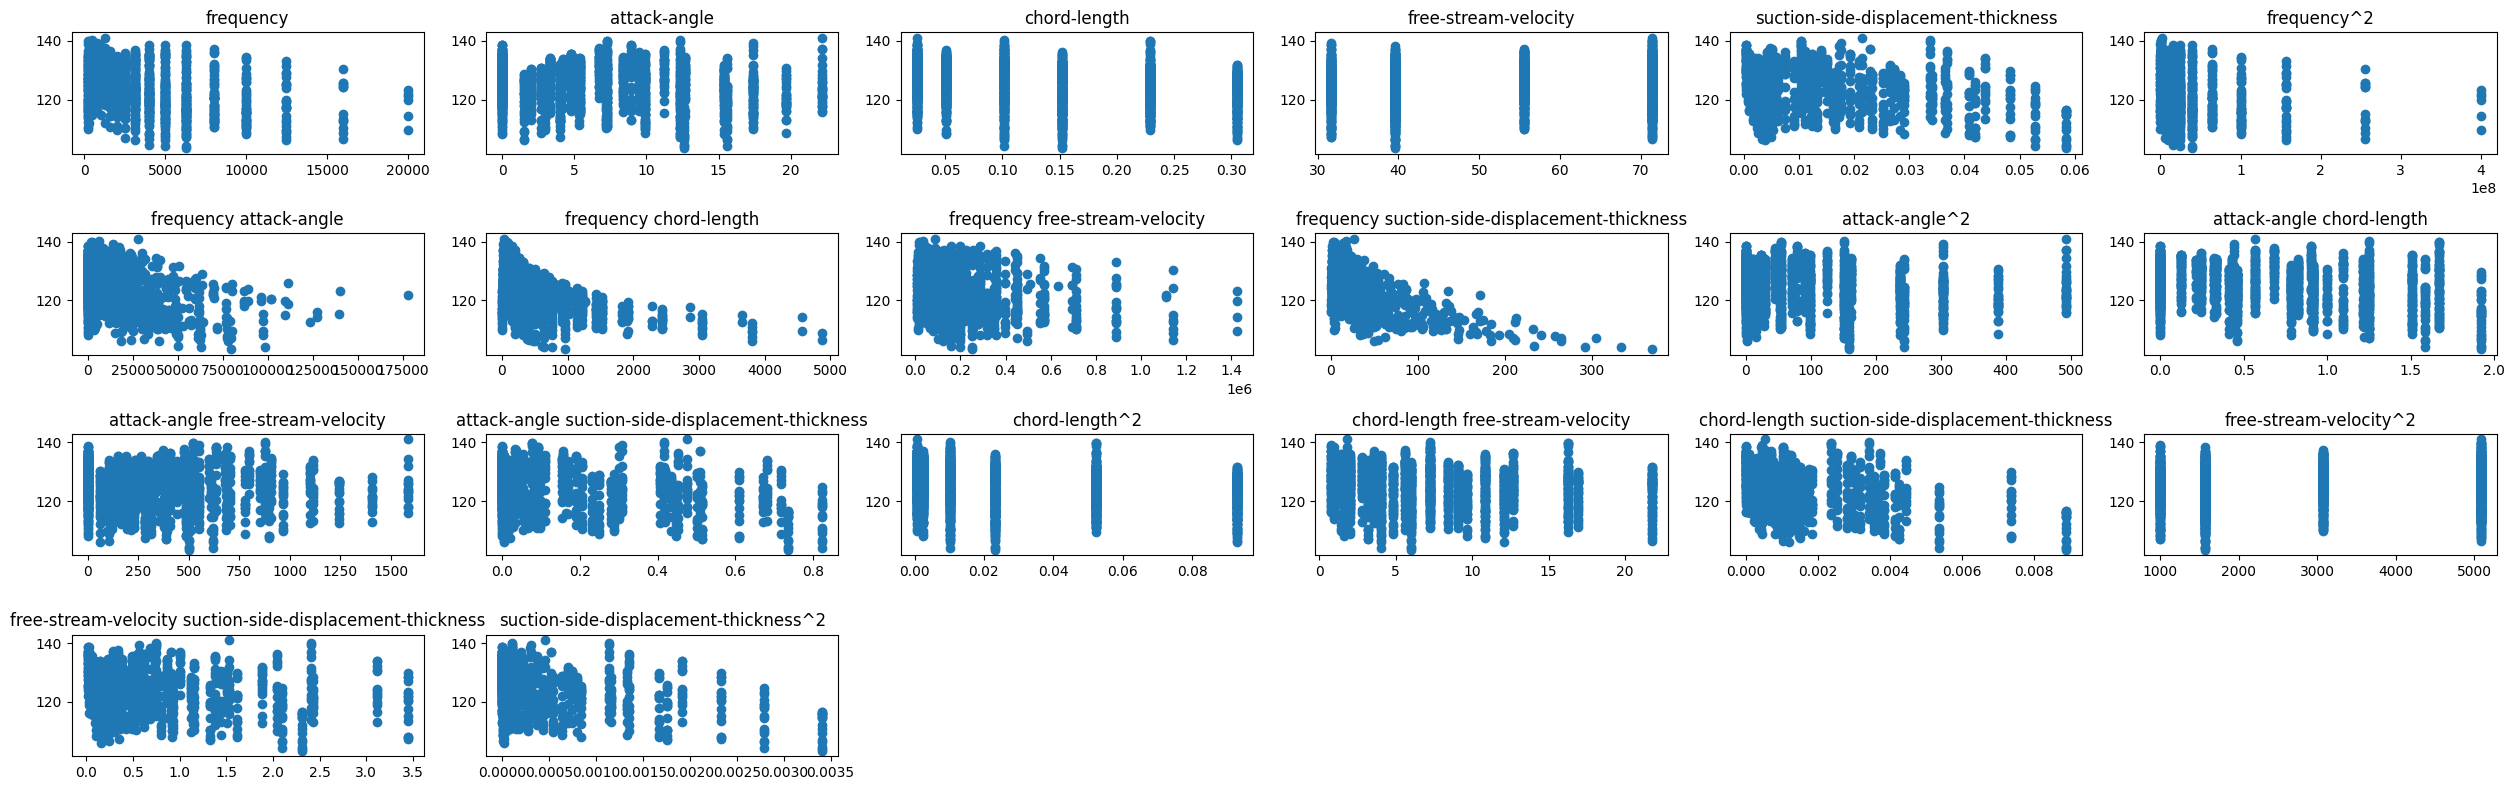

In [33]:
poly = PolynomialFeatures()
X_poly = poly.fit_transform(X)
feature_names = poly.get_feature_names_out(X.columns)

print(X_poly.shape)

plt.figure(figsize=(25, 8))
for i, (column, name) in enumerate(zip(X_poly.T[1:], feature_names[1:])): # [1:] because of bias
    plt.subplot(4, 6, i+1)
    plt.title(name)
    plt.scatter(column, y['scaled-sound-pressure'])

plt.tight_layout()
plt.show()

### Training and testing for single features

_____________
For frequency: 
sklearn MSE = 39.8579651448302
analytical MSE = 39.85796514483172
_____________
For attack-angle: 
sklearn MSE = 47.613302873961175
analytical MSE = 47.61330287396116
_____________
For chord-length: 
sklearn MSE = 44.166946100586216
analytical MSE = 44.16694610058651
_____________
For free-stream-velocity: 
sklearn MSE = 46.65862087527175
analytical MSE = 46.65862087526565
_____________
For suction-side-displacement-thickness: 
sklearn MSE = 44.486219995595135
analytical MSE = 44.48621999559502


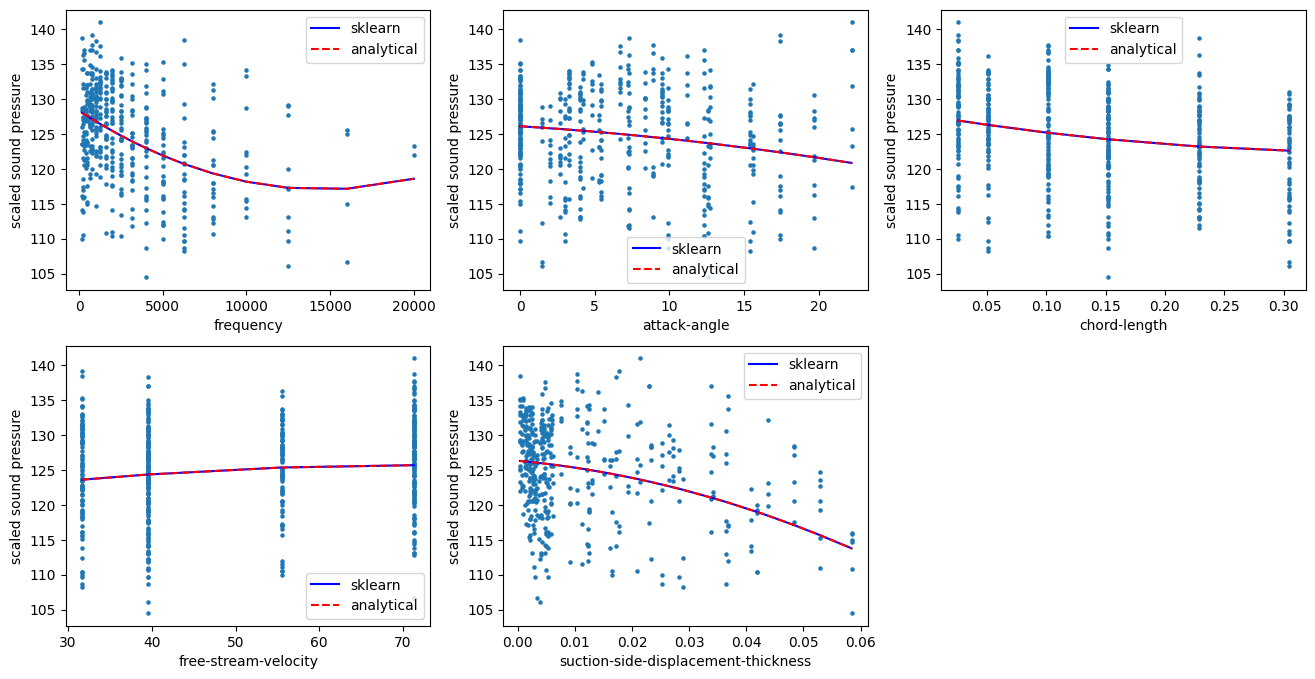

In [34]:
# For each feature
results_per_feature = {}
plt.figure(figsize=(16, 8))

for index, feature in enumerate(X.columns):
    # Preparing dataset for each featuer
    X_cur_feature = X[[feature]]
    poly = PolynomialFeatures()
    X_poly_feature = poly.fit_transform(X_cur_feature)

    X_train_feature, X_test_feature, y_train_feature, y_test_feature = train_test_split(
        X_poly_feature, y, test_size=0.30, random_state=RANDOM_STATE
    )
    
    # Training
    sk_reg = LinearRegression(fit_intercept=False)
    sk_reg.fit(X_train_feature, y_train_feature)

    my_reg = AnalyticalLinearRegression()
    my_reg.fit(X_train_feature, y_train_feature.values.ravel())

    # Testing
    sk_pred = sk_reg.predict(X_test_feature)
    my_pred = my_reg.predict(X_test_feature)

    mse_sk = mean_squared_error(y_test_feature, sk_pred)
    mse_my = mean_squared_error(y_test_feature, my_pred)
    results_per_feature[feature] = (mse_sk, mse_my)
    print("_____________")
    print(f"For {feature}: ")
    print(f"sklearn MSE = {mse_sk}")
    print(f"analytical MSE = {mse_my}")

    # Visualizing
    x_plot = X_test_feature[:, 1] 
    sort_idx = np.argsort(x_plot)

    plt.subplot(2, 3, index + 1)
    plt.scatter(x_plot, y_test_feature, s=5)
    plt.plot(x_plot[sort_idx], sk_pred[sort_idx], c="blue", label="sklearn")
    plt.plot(x_plot[sort_idx], my_pred[sort_idx], c="red", linestyle="dashed", label="analytical")
    plt.xlabel(feature)                    
    plt.ylabel('scaled sound pressure')
    plt.legend()

plt.show()

### Training and testing for all features at once

In [35]:
poly_all = PolynomialFeatures(degree=2)
X_all_poly = poly_all.fit_transform(X)

X_train_all, Xa_test_all, ya_train_all, ya_test_all = train_test_split(
    X_all_poly, y, test_size=0.30, random_state=RANDOM_STATE
)

sk_reg_all = LinearRegression(fit_intercept=False)
sk_reg_all.fit(X_train_all, ya_train_all)

my_reg_all = AnalyticalLinearRegression()
my_reg_all.fit(X_train_all, ya_train_all.values.ravel())

sk_pred_all = sk_reg_all.predict(Xa_test_all)
my_pred_all = my_reg_all.predict(Xa_test_all)
mse_sk_all = mean_squared_error(ya_test_all, sk_pred_all)
mse_my_all = mean_squared_error(ya_test_all, my_pred_all)
print(f"\nAll features: sklearn MSE={mse_sk_all}, analytical MSE={mse_my_all}")


All features: sklearn MSE=18.647994519843873, analytical MSE=18.64799451975683


The best performance can be seen on model trained on all features together

# Ridge regression

### Imports

In [47]:
from sklearn.linear_model import Ridge

### Implementation

In [44]:
class RidgeLinearRegression:
    def _lambda(self, X : np.ndarray, y : np.ndarray): # plug-in lambda coefficent calculation implementation 
        n, p = X.shape
        beta = np.linalg.pinv(X) @ y
        omega = np.linalg.pinv((X.T @ X) / n)
        sigma_squared = np.linalg.norm((y - (X @ beta)))**2 / (n - p)
        
        nominator = sigma_squared * np.trace(omega)
        denominator = (beta.T @ omega @ beta) + (3 * sigma_squared * np.trace(omega@omega) / n)
        return nominator/denominator

    def fit(self, X : np.ndarray, y : np.ndarray) -> None:
        regularization_coefficient = self._lambda(X, y)
        number_of_features = X.shape[1]
        I = np.identity(number_of_features)
        self.weights = np.linalg.inv((X.T @ X) + regularization_coefficient * I) @ X.T @ y

    def predict(self, X) -> np.ndarray:
        return X @ self.weights

### Training (on synthetic dataset fromthe begining)

In [50]:
ridge_lin_reg = RidgeLinearRegression()
ridge_lin_reg.fit(X_train, y_train)
ridge_line = ridge_lin_reg.predict(X_test)

sk_ridge_lin_reg = Ridge()
sk_ridge_lin_reg.fit(X_train, y_train)
sk_ridge_line = ridge_lin_reg.predict(X_test)

### Testing + visualisation

MSE Ridge: 263.47783056292894
MSE Sklearn ridge: 263.47783056292894
RMSE Ridge: 16.232000202160204
RMSE Sklearn ridge: 16.232000202160204


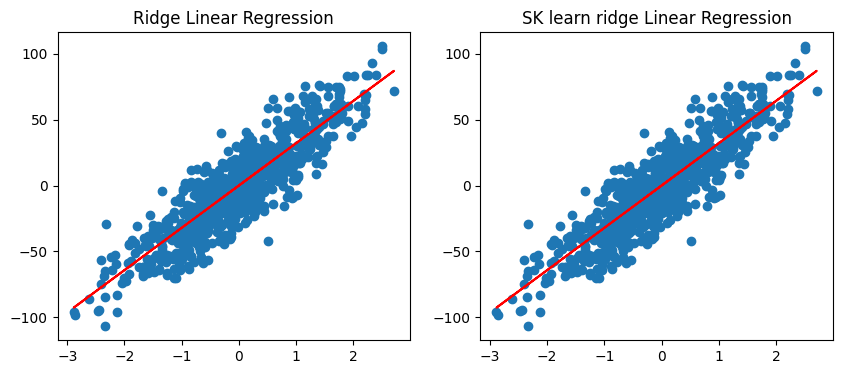

In [53]:
mse_ridge = mean_squared_error(y_test, ridge_line)
mse_ridge_sklearn = mean_squared_error(y_test, sk_ridge_line)
rmse_ridge = root_mean_squared_error(y_test, ridge_line)
rmse_ridge_sklearn = root_mean_squared_error(y_test, sk_ridge_line)

print(f"MSE Ridge: {mse_ridge}")
print(f"MSE Sklearn ridge: {mse_ridge_sklearn}")
print(f"RMSE Ridge: {rmse_ridge}")
print(f"RMSE Sklearn ridge: {rmse_ridge_sklearn}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Ridge Linear Regression")
plt.scatter(X_test, y_test)
plt.plot(X_test, ridge_line, c = 'red')

plt.subplot(1, 2, 2)
plt.title("SK learn ridge Linear Regression")
plt.scatter(X_test, y_test)
plt.plot(X_test, sk_ridge_line, c = 'red')

plt.show()